# **Siti Naia Hesti Rachmawati | 24083010047**

**Dataset**

Dataset sekunder yang digunakan dalam analisis lanjutan ini bersumber dari platform publik komunitas Machine Learning Kaggle, dengan judul resmi kompetisi "Rossmann Store Sales" (tautan: [rossmann store sales](https://www.kaggle.com/competitions/rossmann-store-sales/data) ).

Rossmann merupakan salah satu jaringan drugstore (apotek dan toko kebutuhan sehari-hari) terbesar di Eropa yang berpusat di Jerman. Dataset historis ini merekam metrik operasional dan penjualan harian dari lebih dari 1.000 cabang toko Rossmann pada rentang waktu 2013 hingga 2015. Dataset ini dipilih karena menyediakan variabel prediktor eksternal yang sangat kaya (seperti jarak kompetitor, hari libur sekolah, dan kalender promosi), sehingga memberikan representasi empiris yang sangat akurat mengenai perilaku konsumen ritel di pasar Eropa untuk dikomparasikan dengan dataset pasar Amerika.

In [1]:
# @title import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
# @title load dataset
df_train = pd.read_csv('/content/train.csv')
df_store = pd.read_csv('/content/store.csv')

# Menggabungkan data historis (train) dengan profil toko (store)
df = df_train.merge(df_store, on='Store', how='left')

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [3]:
df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.085652,7715.323700,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.222866,3.211832,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.690228,5.992644,1900.0,2006.0,2010.0,2013.0,2015.0


> Karena dataset Rossmann berbeda dengan Walmart, terdapat penyesuaian identifikasi variabel yang ekuivalen:

>> Variabel Target: Sales (Menggantikan Weekly_Sales).

>> Variabel Fitur: Store, Date, Customers, Promo, StateHoliday, CompetitionDistance, dll. (Tidak ada variabel Dept karena Rossmann adalah apotek/toko serba ada skala kecil yang performanya diukur per toko penuh, bukan per departemen).

> Tipe Data: Mayoritas Numerik (Sales, Customers), Kategorikal/Teks (Date, StateHoliday), dan Numerik Diskrit (Store).

> Fungsi Variabel dalam Konteks Prediksi:

>> Store: Mengidentifikasi cabang apotek Rossmann. Tiap toko punya letak geografis (misal di stasiun vs perumahan) yang memengaruhi volume pembeli.

>> Date: Penunjuk waktu untuk menangkap seasonality (contoh: masa libur sekolah Eropa sangat memengaruhi trafik pelanggan).

>> Sales (Target): Nilai penjualan aktual yang menjadi label untuk dipelajari oleh model Machine Learning.

>> Promo (Pengganti MarkDown): Penanda apakah toko sedang menjalankan promosi pada hari itu. Di industri ritel obat/kosmetik, promo sangat krusial menggerakkan target Sales.

**missing values**

**Metode Penanganan Missing Value**

> Sebelum melakukan pemodelan Machine Learning, data yang kosong (NaN/Null) wajib ditangani karena algoritma tidak dapat memproses nilai yang hilang. Terdapat tiga metode utama yang secara umum digunakan untuk mengatasi missing value, yaitu:

> 1. Penghapusan Data (Deletion / Dropping)

>> Metode ini membuang observasi (baris) atau fitur (kolom) yang memiliki nilai kosong.
Kelebihan: Sangat mudah dan menjaga keaslian data yang tersisa. Namun berisiko membuang terlalu banyak informasi penting jika persentase data yang dihapus terlalu besar. Umumnya, penghapusan kolom hanya dilakukan jika persentase kekosongannya sangat tinggi (misal >30%) dan fiturnya kurang relevan.

> 2. Imputasi Statistik (Statistical Imputation)

>> Metode ini mengisi nilai yang kosong menggunakan nilai representatif dari data yang ada.

>> Mean (Rata-rata): Digunakan untuk data numerik yang berdistribusi normal (tanpa outlier).

>> Median (Nilai Tengah): Digunakan untuk data numerik yang memiliki outlier atau distribusinya skewed, karena median kebal terhadap nilai ekstrem.

>> Mode (Modus): Digunakan untuk mengisi data kategorikal (teks/label) berdasarkan kelas yang paling sering muncul.

> 3. Imputasi Nilai Konstan (Constant / Domain-Specific Imputation)

>> Metode ini mengisi kekosongan dengan nilai absolut yang spesifik (misalnya angka 0 atau teks "Unknown"). Pendekatan ini digunakan ketika ketiadaan data itu sendiri merupakan sebuah informasi. Contohnya, jika kolom "Jumlah Diskon" kosong, kemungkinan besar artinya barang tersebut memang tidak sedang diskon (sehingga wajar diisi dengan angka 0).

In [6]:
# @title missing values
print(df.isnull().sum())

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


In [7]:
# @title penanganan missing value

# Kolom CompetitionDistance
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

# Kolom Promo2SinceWeek & Promo2SinceYear
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

# Kolom CompetitionOpenSinceMonth & CompetitionOpenSinceYear
df.drop(columns=['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'], inplace=True)

print("\nMissing Values Setelah Penanganan")
print(df.isna().sum())


Missing Values Setelah Penanganan
Store                  0
DayOfWeek              0
Date                   0
Sales                  0
Customers              0
Open                   0
Promo                  0
StateHoliday           0
SchoolHoliday          0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
Promo2SinceWeek        0
Promo2SinceYear        0
PromoInterval          0
dtype: int64


**Analisis dan Interpretasi Penanganan Missing Value (Dataset Rossmann)**

> Berdasarkan pengecekan awal menggunakan df.isnull().sum(), ditemukan masalah missing value dengan karakteristik yang sangat bervariasi. Terdapat kolom yang hanya kosong sedikit (CompetitionDistance = 2.642 baris), namun ada pula kelompok kolom yang kosong dalam jumlah masif (hingga 300.000 dan 500.000 baris). Perbedaan ekstrem ini menuntut penanganan yang spesifik untuk masing-masing variabel berdasarkan logika bisnis (domain knowledge) dari industri ritel.

> 1. Imputasi Median pada CompetitionDistance

>> Kolom ini berisi data numerik kontinu mengenai jarak toko dengan kompetitor. Karena jumlah data yang kosong tergolong sangat kecil dibandingkan total keseluruhan data, metode yang dipilih adalah Imputasi Median. Penggunaan nilai tengah (median) memastikan bahwa rata-rata jarak keseluruhan toko tetap stabil dan tidak terdistorsi oleh adanya outlier jarak (toko yang kompetitornya sangat jauh).

> 2. Imputasi Konstan (Angka 0 & 'None') pada Fitur Promo2

>> Kolom Promo2SinceWeek, Promo2SinceYear, dan PromoInterval memiliki kekosongan hingga 508.031 baris. Secara kontekstual, data ini kosong murni karena pada baris tersebut, status toko sedang tidak mengikuti program promo lanjutan (Promo2 = 0).
Oleh karena itu, missing value di sini diartikan sebagai ketiadaan peristiwa. Metode yang tepat adalah imputasi konstan dengan angka 0 (untuk waktu) dan 'None' (untuk interval). Dengan penanganan ini, algoritma akan dengan cerdas mengenali bahwa angka nol merepresentasikan status promo yang sedang tidak aktif, tanpa merusak pola data lainnya.

> 3. Penghapusan Kolom (Dropping) pada CompetitionOpenSince...

>> Kolom waktu pembukaan kompetitor (Month dan Year) memiliki kekosongan hingga 323.348 baris. Kekosongan ini terjadi karena ketidaktahuan (unknown data), bukan karena ketiadaan kompetitor.
Jika dilakukan imputasi statistik (misal: diisi tahun 2010), hal ini akan menciptakan "sejarah fiktif". Sebaliknya, jika diisi angka 0, akan merusak rentang standar data secara fatal saat proses scaling (algoritma akan mengira kompetitor buka pada tahun 0 Masehi). Mengingat persentase kekosongannya sangat besar dan tingkat kepentingannya (feature importance) jauh di bawah fitur "jarak kompetitor", maka keputusan paling logis dan aman adalah menghapus (drop) kedua kolom tersebut secara permanen untuk meminimalisir noise pada model.

> Melalui kombinasi tiga pendekatan yang disesuaikan dengan karakteristik masing-masing variabel, pengecekan akhir menunjukkan bahwa seluruh kolom telah berada di angka 0 missing value. Dataset kini telah bersih, memiliki integritas matematis yang kuat, dan siap untuk diproses ke tahap rekayasa fitur waktu (datetime extraction).

In [8]:
# @title pengecekan data duplikat
total_duplikat = df.duplicated().sum()
print(f"Ditemukan {total_duplikat} baris duplikat.")

Ditemukan 0 baris duplikat.


In [9]:
# @title mengubah kolom date menjadi datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

**Penyesuaian Granularitas Data (Resampling)**

> Sesuai dengan perintah tugas untuk membuat peramalan mingguan (Weekly Sales, Lag 1-4 Minggu, dan Rolling Mean 4 Minggu), terdapat perbedaan format dasar antara dataset Walmart dan Rossmann. Dataset Rossmann direkam dalam format harian (daily).
Jika dipaksakan membuat fitur Lag langsung pada data mentah ini, yang terbentuk adalah Lag 1 Hari, bukan 1 Minggu. Oleh karena itu, dilakukan tahap agregasi (pengelompokan) data dari harian menjadi mingguan berdasarkan Store, Year, dan Week.

In [10]:
# @title agregasi harian ke mingguan

df_weekly = df.groupby(['Store', 'Year', 'Week']).agg(
    Date=('Date', 'min'),
    Sales=('Sales', 'sum'),
    Customers=('Customers', 'sum'),
    Promo=('Promo', 'sum'),
    CompetitionDistance=('CompetitionDistance', 'first')
).reset_index()

# pembuatan fitur baru dari kolom date (year, month, week, day_of_week)
df_weekly = df_weekly.assign(
    Year = df_weekly['Date'].dt.year,
    Month = df_weekly['Date'].dt.month,
    Week = df_weekly['Date'].dt.isocalendar().week.astype(int),
    Day_of_Week = df_weekly['Date'].dt.dayofweek
)

df_weekly.sort_values(by=['Store', 'Date'], inplace=True, ignore_index=True)

print("Data Harian berhasil dikonversi menjadi Mingguan")
df_weekly.head()

Data Harian berhasil dikonversi menjadi Mingguan


,Store,Year,Week,Date,Sales,Customers,Promo,CompetitionDistance,Month,Day_of_Week
0,1,2013,1,2013-01-01,28895,3594,0,1270.0,1,1
1,1,2013,2,2013-01-07,32952,3918,5,1270.0,1,0
2,1,2013,3,2013-01-14,25978,3417,0,1270.0,1,0
3,1,2013,4,2013-01-21,33071,3862,5,1270.0,1,0
4,1,2013,5,2013-01-28,28693,3561,0,1270.0,1,0


In [11]:
df_weekly.tail()

,Store,Year,Week,Date,Sales,Customers,Promo,CompetitionDistance,Month,Day_of_Week
146020,1115,2015,27,2015-06-29,48130,2982,5,5350.0,6,0
146021,1115,2015,28,2015-07-06,36233,2531,0,5350.0,7,0
146022,1115,2015,29,2015-07-13,45927,3057,5,5350.0,7,0
146023,1115,2015,30,2015-07-20,35362,2504,0,5350.0,7,0
146024,1115,2015,31,2015-07-27,43551,2621,5,5350.0,7,0


In [12]:
# @title membuat fitur lag dan rolling mean

# membuat objek groupby berdasarkan toko
sales_grouped = df_weekly.groupby('Store')['Sales']

# pembuatan lag feature (1, 2, dan 4 minggu ke belakang)
df_weekly['Lag_1W'] = sales_grouped.shift(1)
df_weekly['Lag_2W'] = sales_grouped.shift(2)
df_weekly['Lag_4W'] = sales_grouped.shift(4)

# pembuatan fitur rolling mean (rata-rata 4 minggu berjalan)
df_weekly['Roll_Mean_4W'] = sales_grouped.transform(lambda x: x.rolling(4).mean())

df_weekly.dropna(subset=['Lag_1W', 'Lag_2W', 'Lag_4W', 'Roll_Mean_4W'], inplace=True)
df_weekly.reset_index(drop=True, inplace=True)

display(df_weekly[['Store', 'Date', 'Sales', 'Lag_1W', 'Lag_4W', 'Roll_Mean_4W']].head())

,Store,Date,Sales,Lag_1W,Lag_4W,Roll_Mean_4W
0,1,2013-01-28,28693,33071.0,28895.0,30173.50
1,1,2013-02-04,35771,28693.0,32952.0,30878.25
2,1,2013-02-11,27880,35771.0,25978.0,31353.75
3,1,2013-02-18,32951,27880.0,33071.0,31323.75
4,1,2013-02-25,27027,32951.0,28693.0,30907.25


**Analisis dan Interpretasi Time Series Feature Engineering**

> Langkah pertama yang dilakukan sebelum pergeseran data adalah mengelompokkan dataset berdasarkan Store. Pemisahan entitas ini bersifat krusial dan wajib (mandatory). Jika data tidak diisolasi per toko, maka nilai penjualan minggu terakhir dari Toko 1 akan bergeser dan masuk menjadi riwayat historis (Lag) untuk minggu pertama di Toko 2. Hal tersebut akan menciptakan kebocoran data (data leakage) dan merusak logika prediksi.

> Berdasarkan tabel output, baris observasi paling awal (indeks ke-0) kini dimulai pada tanggal 28 Januari 2013, bukan di awal Januari. Hal ini merupakan bukti konkret bahwa fungsi dropna telah bekerja dengan sempurna.
Pembentukan fitur Lag_4W (riwayat 4 minggu ke belakang) dan Roll_Mean_4W secara otomatis akan menghasilkan nilai kosong (NaN) pada empat minggu pertama di setiap toko karena rekam jejak historisnya belum cukup panjang. Menghapus empat baris awal ini adalah langkah pengorbanan (trade-off) yang sangat sepadan demi mendapatkan variabel prediktor historis yang kuat, sekaligus memastikan algoritma Machine Learning terhindar dari error komputasi akibat keberadaan missing value.

> Untuk memverifikasi keakuratan fungsi matematis, observasi dapat difokuskan pada indeks ke-1 (tanggal 4 Februari 2013):

>> Target Aktual (Sales): Mencatat angka 35.771 Euro, yang menjadi nilai target untuk diprediksi.

>> Fitur Lag (Lag_1W): Mencatat angka 28.693 Euro. Jika dikonfirmasi ke baris atasnya (indeks 0, tanggal 28 Jan), angka ini adalah nilai Sales persis dari satu minggu sebelumnya. Transformasi ini berhasil mengubah struktur data dari deret waktu murni menjadi format regresi standar (variabel independen memprediksi variabel dependen).

>> Fitur Data Smoothing (Roll_Mean_4W): Mencatat angka 30.878,25. Ini adalah nilai rata-rata pergerakan penjualan selama sebulan terakhir. Fitur ini berfungsi sebagai peredam noise (penghalus data). Jika model regresi melihat adanya lonjakan ekstrem pada Lag_1W, model akan membandingkannya dengan Roll_Mean_4W untuk memutuskan apakah lonjakan tersebut merupakan tren fundamental atau hanya anomali sesaat.

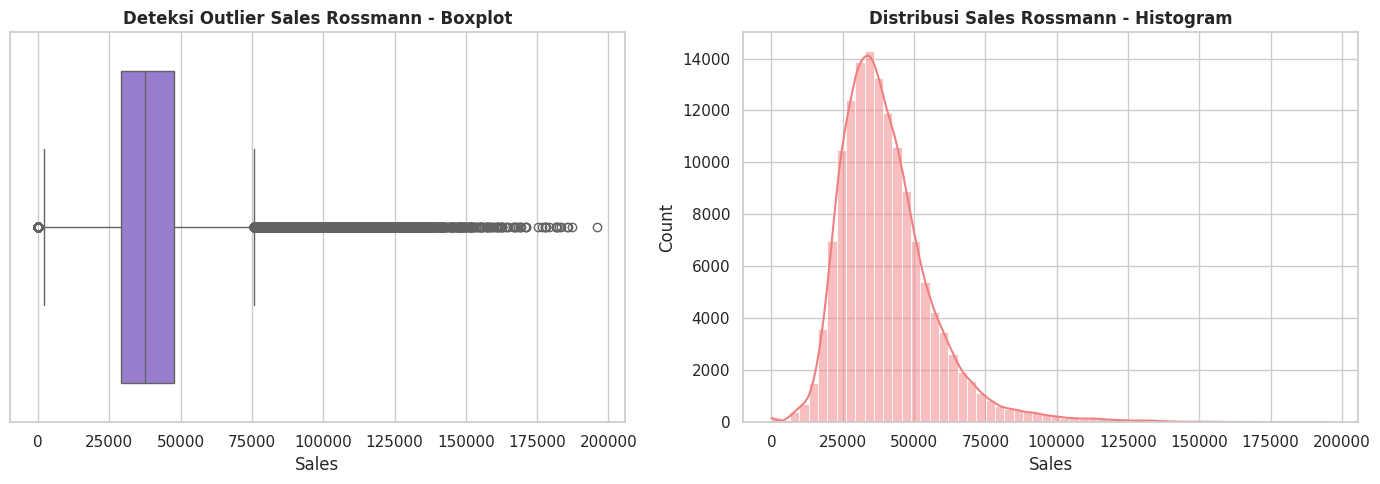

In [13]:
# @title mendeteksi outlier (boxplot & histogram)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot
sns.boxplot(x=df_weekly['Sales'], ax=axes[0], color='mediumpurple')
axes[0].set_title('Deteksi Outlier Sales Rossmann - Boxplot', fontweight='bold')

# histogram
sns.histplot(df_weekly['Sales'], bins=60, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribusi Sales Rossmann - Histogram', fontweight='bold')

plt.tight_layout()
plt.show()

1. Boxplot

> Pada grafik Boxplot, terlihat bahwa mayoritas data penjualan (yang diwakili oleh kotak/IQR) berada di rentang yang relatif rendah dan padat. Namun, temuan paling krusial adalah adanya konsentrasi titik-titik hitam yang sangat tebal memanjang ke atas jauh melewati garis kumis atas (upper whisker).

> Secara statistik, titik-titik ini adalah outlier (pencilan). Namun dalam konteks bisnis ritel, nilai-nilai ekstrem yang sangat tinggi ini bukanlah "data error/sampah", melainkan merepresentasikan minggu-minggu anomali di mana penjualan meledak drastis (kemungkinan besar akibat musim liburan, event promosi besar, atau panic buying).

2. Histogram

> Grafik Histogram mengonfirmasi temuan pada Boxplot. Terlihat bahwa distribusi data tidak berbentuk lonceng simetris (Normal), melainkan memiliki Kemencengan ke Kanan (Right-Skewed / Positive Skewness).

> Puncak bukit (modus) berada di sebelah kiri yang menunjukkan rata-rata penjualan reguler, sementara terdapat "ekor" (tail) yang sangat panjang menjulur ke kanan. Ekor panjang ini membuktikan frekuensi keberadaan minggu-minggu dengan angka penjualan historis yang jauh melampaui batas wajar.



---

> Berdasarkan visualisasi Boxplot dan Histogram, outlier yang ada murni merepresentasikan fenomena bisnis yang valid (lonjakan musiman dan promosi), bukan merupakan error input data.

> Oleh karena itu, metode penghapusan baris (Trimming / IQR) tidak digunakan karena akan menghilangkan informasi krusial mengenai perilaku pasar saat peak season. Sebagai jalan tengah untuk menjaga stabilitas algoritma Machine Learning tanpa membuang data, metode yang dipilih adalah Capping (Winsorization) pada Persentil ke-99. Nilai penjualan yang melampaui batas 1% tertinggi akan dibatasi (ditimpa) agar sama dengan nilai batas persentil tersebut.

**penanganan outlier**

**Metode Penanganan Outlier (Pencilan)**

> Dalam analisis data prediktif, outlier adalah nilai ekstrem yang menyimpang sangat jauh dari observasi lainnya. Jika dibiarkan, nilai ini dapat menarik garis regresi secara paksa dan merusak akurasi model matematis. Terdapat beberapa metode standar untuk menangani outlier, antara lain:

> 1. Pemotongan Data (Trimming / Deletion)

>> Metode ini secara harfiah menghapus baris data yang teridentifikasi sebagai pencilan (biasanya menggunakan batas Interquartile Range / IQR atau batas Z-Score).

>> Kelebihan: Menghasilkan dataset yang sangat bersih dan terpusat.

>> Kekurangan: Berisiko tinggi menghilangkan informasi penting, terutama jika anomali tersebut merupakan fenomena alamiah/bisnis (bukan error input).

> 2. Pembatasan Nilai (Winsorization / Capping)

>> Metode ini tidak menghapus observasi, melainkan mengganti (menimpa) nilai yang melewati batas ekstrem dengan nilai ambang batas tersebut. Umumnya menggunakan batas persentil (contoh: persentil ke-1 untuk batas bawah, persentil ke-99 untuk batas atas).

>> Kelebihan: Mempertahankan jumlah observasi data (no data loss) dan mempertahankan indikasi adanya kejadian ekstrem tanpa membiarkan nilainya merusak skala model.

> 3. Transformasi Matematis (Log / Box-Cox Transformation)

>> Metode ini mengenakan fungsi logaritma atau akar pada variabel, sehingga sebaran data yang memiliki "ekor panjang" (skewed) tertarik merapat mendekati distribusi normal, tanpa mengubah urutan asli datanya.

In [14]:
# @title penanganan outlier menggunakan metode capping (winsorization) persentil 99%

# menentukan batas atas (persentil ke-99)
batas_atas = df_weekly['Sales'].quantile(0.99)
print(f"Batas atas (Persentil 99%) ditetapkan di angka: {batas_atas:.2f} Euro")

df_weekly['Sales'] = np.where(df_weekly['Sales'] > batas_atas, batas_atas, df_weekly['Sales'])

print("Penanganan Outlier (Capping) Berhasil Dilakukan")
display(df_weekly[['Sales']].describe().T)

Batas atas (Persentil 99%) ditetapkan di angka: 99996.08 Euro
Penanganan Outlier (Capping) Berhasil Dilakukan


,count,mean,std,min,25%,50%,75%,max
Sales,141565.0,40093.190049,15902.896425,0.0,29151.0,37454.0,47787.0,99996.08


**Analisis dan Interpretasi Penanganan Outlier (Target Penjualan)**

> Dalam industri ritel (Rossmann), titik-titik outlier atas pada variabel target Sales bukanlah data "sampah" atau error sensor, melainkan representasi dari fenomena bisnis yang sangat valid, seperti panic buying, promo cuci gudang, atau lonjakan musim libur Natal.

> Jika metode penghapusan (Trimming / IQR) digunakan, kita akan membuang ratusan minggu paling menguntungkan dari rekam jejak toko. Akibatnya, model Machine Learning akan menjadi "buta" dan gagal memprediksi lonjakan penjualan di musim liburan mendatang. Oleh karena itu, metode Capping (Winsorization) di batas Persentil 99% dipilih sebagai jalan tengah terbaik: menjaga integritas jumlah baris data, mengamankan informasi momen peak season, namun tetap membatasi nominal ledakannya agar tidak merusak bobot komputasi algoritma.

> Berdasarkan ringkasan statistik deskriptif dari output kode, persentil ke-99 (batas atas) jatuh pada angka penjualan sebesar 99.996,08 Euro.
Tabel evaluasi menunjukkan bahwa nilai maksimum (max) dari seluruh data kini mentok secara presisi di angka 99.996,08 Euro. Hal ini membuktikan secara definitif bahwa algoritma np.where telah berhasil memangkas seluruh nilai penjualan yang melampaui batas tersebut (misalnya nilai 150.000 atau 200.000) dan menyeragamkannya menjadi setara dengan nilai batas atas, tanpa memengaruhi rentang kuartil data normal di bawahnya (kuartil 25%, 50%, dan 75% tetap terjaga dengan baik).

**perbedaan min max scaling dengan z score**

> Min-Max Scaling: Mengubah rentang seluruh data secara linier sehingga nilai minimum menjadi 0 dan nilai maksimum menjadi 1. Rentangnya sangat kaku dan distribusinya mudah rusak jika terdapat outlier yang ekstrem.

> Standardization (Z-score): Mengubah sebaran data sehingga memiliki rata-rata (mean) 0 dan standar deviasi 1. Rentang nilainya tidak dibatasi (bisa memuat nilai negatif) dan jauh lebih stabil (robust) saat menangani data yang masih memiliki outlier.

In [15]:
# @title standardisasi/normalisasi variabel numerik
kolom_numerik = ['Customers', 'CompetitionDistance']

scaler = StandardScaler()
df_weekly[kolom_numerik] = scaler.fit_transform(df_weekly[kolom_numerik])

print("\nStandardisasi Z-Score untuk Customers dan CompetitionDistance Selesai!")
display(df_weekly[kolom_numerik].head())


Standardisasi Z-Score untuk Customers dan CompetitionDistance Selesai!


,Customers,CompetitionDistance
0,-0.360926,-0.538755
1,-0.135500,-0.538755
2,-0.328782,-0.538755
3,-0.226008,-0.538755
4,-0.394761,-0.538755


> Berdasarkan lima baris pertama dari hasil transformasi, nilai Customers dan CompetitionDistance yang tadinya berupa angka riil yang besar kini telah berubah menjadi skala desimal positif dan negatif (contoh: -0.360926).
Secara matematis, nilai negatif mengindikasikan bahwa pada minggu tersebut, jumlah pelanggan atau jarak kompetitor berada di bawah rata-rata keseluruhan. Sebaliknya, nilai positif menandakan observasi tersebut berada di atas rata-rata. Perubahan ini secara instan menyejajarkan kedua fitur tersebut ke dalam satu "bahasa" skala yang sama.

In [16]:
display(df_weekly[kolom_numerik].describe())

,Customers,CompetitionDistance
count,1.415650e+05,1.415650e+05
mean,-4.617662e-17,-5.219966e-17
std,1.000004e+00,1.000004e+00
min,-1.867007e+00,-7.009751e-01
25%,-5.690109e-01,-6.114297e-01
50%,-2.175497e-01,-4.011927e-01
75%,2.836314e-01,1.892878e-01
max,1.090063e+01,9.141232e+00


> Tabel statistik deskriptif memberikan bukti empiris bahwa fungsi StandardScaler telah bekerja secara sempurna dan presisi tanpa merusak data:

>> Pembuktian Rata-rata Terpusat (Mean = 0): Nilai mean untuk Customers tercatat sebesar -4.617e-17. Huruf e-17 adalah Notasi Ilmiah (Scientific Notation) yang berarti nilai tersebut adalah $0.00000000000000004$. Mengingat batas presisi komputasi floating point, angka ini secara mutlak diartikan sebagai 0. Hal ini membuktikan bahwa titik pusat (gravitasi) dari kedua variabel telah sukses digeser tepat ke angka nol.

>> Pembuktian Skala Sebaran (Standard Deviation = 1): Nilai std untuk kedua variabel menampilkan angka 1.000004e+00. Notasi e+00 menandakan pangkat nol ($10^0$), sehingga angka ini tidak dikali atau dibagi dan dibaca murni sebagai 1.

> Melalui pembuktian statistik di atas, dapat disimpulkan bahwa kedua fitur prediktor numerik kini telah ekuivalen sepenuhnya (Mean = 0, Std = 1). Algoritma Machine Learning kini dapat secara objektif mempelajari bobot korelasi dari masing-masing variabel terhadap Sales tanpa terdistraksi atau bias oleh besaran nominal aslinya.

**mengapa pada time series data tidak boleh dilakukan shuffle sebelum split.**

> Pada pemodelan data konvensional (misal: klasifikasi kategori pelanggan), data sangat disarankan untuk diacak (shuffle) sebelum dibagi, agar model mendapatkan sampel yang mewakili seluruh populasi secara merata. Namun pada data Time Series, urutan kronologis adalah struktur informasi yang paling berharga, karena filosofinya adalah menggunakan data masa lalu untuk meramalkan masa depan.

> Jika parameter shuffle diaktifkan (True), baris observasi dari masa depan (misalnya: pola akhir tahun 2015) berpotensi bocor dan masuk ke dalam data latih (Training Set), sementara data masa lalu terlempar ke Testing Set. Fenomena ini disebut Data Leakage (Kebocoran Data) / Look-ahead Bias. Jika ini terjadi, evaluasi model akan terlihat memiliki akurasi yang nyaris sempurna secara artifisial, namun akan gagal total saat dideploy ke produksi riil karena model tersebut secara tidak sah telah "mengintip" kunci jawaban dari masa depan. Oleh karena itu, pemotongan wajib dilakukan secara sekuensial (linier) membelah garis waktu.

In [17]:
# @title pembagian dataset (80% train, 20% test)

df_weekly.sort_values(by=['Store', 'Date'], inplace=True)

X = df_weekly.drop(columns=['Sales', 'Date'])
y = df_weekly['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

print(f"Total keseluruhan observasi: {df_weekly.shape[0]} baris")
print(f"Data Training (80%): {X_train.shape[0]} baris")
print(f"Data Testing (20%): {X_test.shape[0]} baris\n")

Total keseluruhan observasi: 141565 baris
Data Training (80%): 113252 baris
Data Testing (20%): 28313 baris



> Variabel target (Sales) diekstrak ke dalam variabel dependen y. Pada variabel independen/prediktor (X), dilakukan penghapusan terhadap kolom Sales dan kolom Date. Penghapusan objek Date merupakan kewajiban teknis karena algoritma regresi standar tidak dapat mengomputasi format datetime mentah. Hal ini tidak menjadi masalah karena informasi temporal/waktu dari tanggal tersebut telah diekstraksi ke dalam bentuk numerik yang bisa dibaca komputer (Year, Month, Week, Day_of_Week).

> Menggunakan modul train_test_split dengan penjagaan urutan (shuffle=False), total 141.565 baris observasi telah berhasil dibelah sempurna menjadi rasio 80:20.

>> Data Training (113.252 baris): Merepresentasikan 80% garis waktu masa lalu. Blok data raksasa inilah yang akan dijadikan arena belajar bagi algoritma untuk mengenali korelasi matematis antara jarak kompetitor, efektivitas promosi, dan siklus musiman terhadap total penjualan.

>> Data Testing (28.313 baris): Merepresentasikan 20% blok waktu paling akhir (masa depan relatif). Blok data ini diisolasi dan "disembunyikan" dari algoritma. Fungsinya murni sebagai simulator dunia nyata untuk melakukan validasi objektif terhadap kemampuan peramalan model yang telah dilatih.

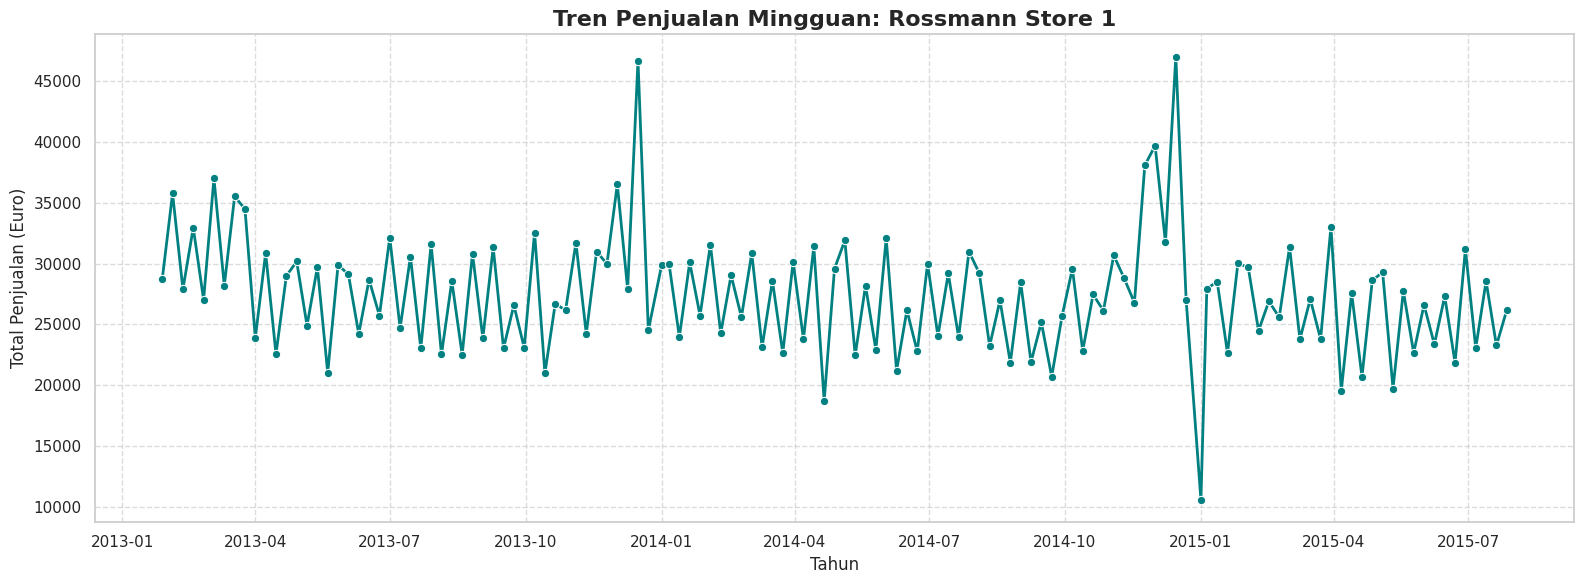

In [18]:
# @title visualisasi tren penjualan mingguan untuk salah satu toko

store_1 = df_weekly[df_weekly['Store'] == 1]

plt.figure(figsize=(16, 6))
sns.lineplot(data=store_1, x='Date', y='Sales', color='teal', linewidth=2, marker='o')

plt.title('Tren Penjualan Mingguan: Rossmann Store 1', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Penjualan (Euro)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Analisis dan Interpretasi Pola Penjualan (Rossmann Store 1)**

> Berdasarkan plot pergerakan total penjualan mingguan untuk Store 1 pada rentang awal 2013 hingga pertengahan 2015, dapat ditarik beberapa kesimpulan visual mengenai perilaku konsumen:

> 1. Volatilitas Tinggi dan Efek Promosi

>> Grafik menampilkan garis bergerigi yang sangat tajam (naik-turun secara drastis dari minggu ke minggu). Fluktuasi ekstrem jangka pendek ini merepresentasikan sensitivitas konsumen ritel terhadap program diskon (Promo). Minggu-minggu di mana grafik memantul naik kemungkinan besar adalah minggu berjalannya promo, sedangkan lembah grafik adalah minggu reguler tanpa promo.

> 2. Siklus Puncak Liburan (Holiday Seasonality)

>> Terdapat pola lonjakan penjualan yang identik dan berulang (spikes) di kuartal keempat setiap tahunnya. Puncak absolut tertinggi terjadi mendekati akhir tahun 2013 (melampaui 45.000 Euro) dan pola serupa kembali terulang di penghujung tahun 2014. Ini membuktikan bahwa momentum liburan Natal dan akhir tahun merupakan tulang punggung pendapatan (revenue generator) utama bagi toko ini.

> 3. Anomali Penurunan Tajam (Drop/Slump)

>> Selain lonjakan ke atas, terdapat anomali penurunan yang sangat curam di awal tahun 2015 (anjlok mendekati level 10.000 Euro). Fenomena ini dapat diartikan sebagai post-holiday slump (kelesuan daya beli masyarakat setelah menghabiskan uang di libur Natal), atau kemungkinan adanya periode di mana toko tutup selama beberapa hari pada minggu tersebut.

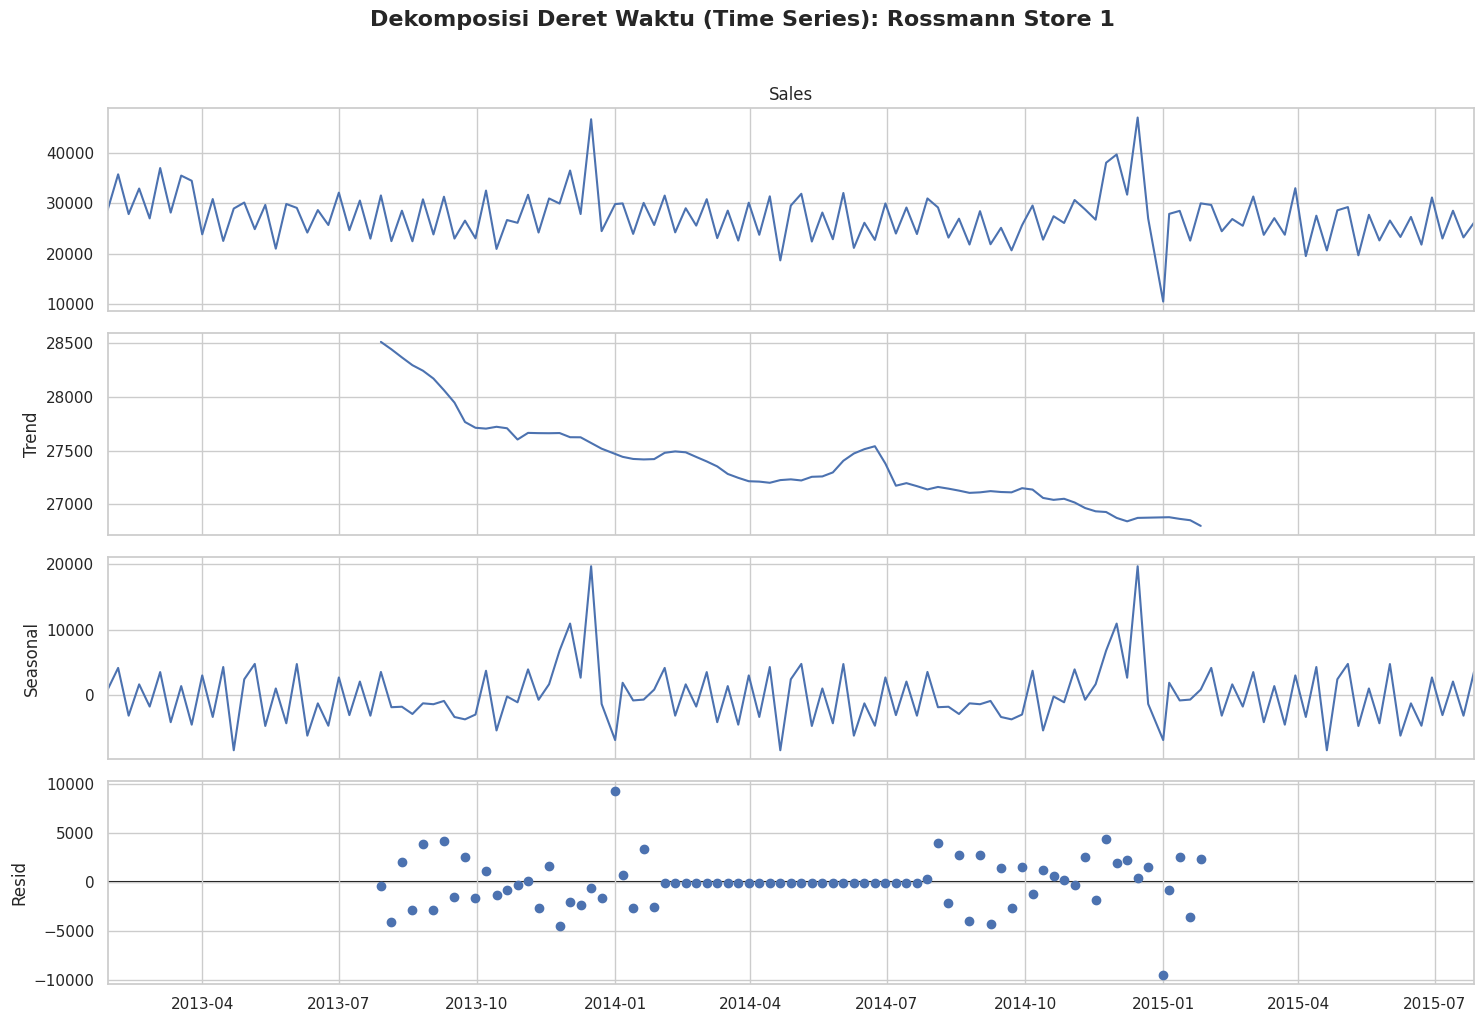

In [19]:
# @title visualisasi trend, seasonality, noise

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

store_1_ts = store_1.set_index('Date')['Sales']
dekomposisi = seasonal_decompose(store_1_ts, model='additive', period=52)

fig = dekomposisi.plot()
fig.set_size_inches(15, 10)
plt.suptitle('Dekomposisi Deret Waktu (Time Series): Rossmann Store 1', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> 1. Komponen Tren (Trend / Panel Kedua)

>> Grafik tren berhasil membuang seluruh noise harian/mingguan dan menampilkan arah fundamental bisnis. Berlawanan dengan grafik data aktual (Sales) yang terlihat konstan, komponen tren justru membongkar fakta bahwa toko ini mengalami pelemahan secara perlahan (downward trend). Penjualan fundamentalnya merosot dari level rata-rata 28.500 Euro di pertengahan 2013, turun hingga menyentuh dasar di kisaran 26.800 Euro pada awal 2015. Informasi ini sangat krusial bagi manajemen untuk mengevaluasi strategi bisnis jangka panjang mereka yang ternyata sedang menurun secara fundamental.

> 2. Komponen Musiman (Seasonal / Panel Ketiga)

>> Panel ini membuktikan keberadaan pola musiman tahunan yang sangat kuat dan presisi. Pola gelombang berulang secara identik di setiap tahunnya. Lonjakan musiman tertinggi (peak season) selalu terjadi di akhir tahun (menembus angka tambahan +20.000 Euro di atas rata-rata), yang digerakkan oleh momentum libur Natal dan Tahun Baru Eropa. Di luar itu, terdapat juga riak-riak musiman kecil yang terjadi secara periodik sepanjang tahun (kemungkinan akibat libur Paskah atau musim panas).

> 3. Komponen Acak/Residu (Residual / Panel Keempat)

>> Panel terbawah ini menampilkan anomali atau "kejutan" yang berada di luar kendali tren maupun musim. Sebagian besar titik residu tersebar normal di sekitar garis nol. Namun, terdapat temuan anomali ekstrem yang sangat menarik:

>> - Terdapat satu titik residu positif raksasa di awal 2014 (mendekati +10.000), yang mengindikasikan adanya kejadian luar biasa yang mendongkrak penjualan (misal: event lokal di dekat toko atau kelangkaan barang di kompetitor).

>> - Terdapat satu titik residu negatif ekstrem di awal 2015 (jatuh menembus -10.000), yang sangat selaras dengan anomali penurunan curam pada grafik data aktual. Hal ini menegaskan adanya disrupsi fatal (seperti operasional toko terhenti, cuaca ekstrem, atau masalah suplai) pada minggu tersebut yang sama sekali tidak bisa diprediksi oleh siklus kalender normal.

**Analisis Komparatif dan Evaluasi Mendalam: Walmart vs. Rossmann**

> Tugas ketiga ini mengeksekusi metode prapemrosesan dan feature engineering time series yang identik pada dua dataset ritel yang berbeda: Walmart (Amerika Serikat) dan Rossmann (Eropa/Jerman). Dari hasil komparasi, ditemukan perbedaan fundamental yang berdampak langsung pada strategi pemodelan Machine Learning.

> 1. Perbandingan Karakteristik dan Granularitas Data

>> Walmart: Berfokus pada indikator ekonomi makro eksternal (Suhu, Harga BBM, Consumer Price Index, dan Tingkat Pengangguran). Struktur datanya sudah berbentuk mingguan per departemen.

>> Rossmann: Berfokus pada operasional toko mikro dan persaingan lokal (Jarak Kompetitor, Kalender Promo Harian, Tipe Toko). Data mentahnya bersifat harian (daily), sehingga menuntut perlakuan ekstra berupa agregasi data (Resampling) menjadi mingguan agar sepadan (apple-to-apple) dengan variabel Lag dan Rolling Mean pada pemodelan.

> 2. Evaluasi Penanganan Preprocessing (Outlier & Missing Value)

> Perbedaan karakteristik data memaksa adanya improvisasi dalam metode pembersihan:

>> Missing Value: Pada Walmart, kekosongan diasumsikan murni sebagai ketiadaan event (MarkDown diisi 0). Pada Rossmann, perlakuannya lebih kompleks. Variabel waktu (CompetitionOpenYear) yang kosong dalam jumlah masif harus dihapus (Drop) untuk mencegah bias skala matematis yang fatal, sedangkan jarak kompetitor diimputasi dengan Median.

>> Outlier Target (Sales): Ini adalah evaluasi paling krusial. Pada tugas sebelumnya, pencilan mungkin dipangkas (Trimming / IQR). Namun, analisis mendalam pada Rossmann membuktikan bahwa outlier atas adalah representasi peak season (Natal/Paskah). Oleh karena itu, metode Capping (Persentil 99%) dieksekusi. Evaluasinya: Capping jauh lebih superior untuk data ritel karena berhasil menjaga integritas data historis tanpa merusak bobot algoritma.

> 3. Komparasi Pola Time Series (Trend, Seasonality, Noise)

> Hasil visualisasi dan ekstraksi seasonal_decompose membongkar perbedaan perilaku konsumen antarbeneua:

>> Tren Fundamental: Walmart cenderung memiliki stabilitas pertumbuhan yang merangkak naik perlahan. Sebaliknya, Store 1 Rossmann menunjukkan tren pelemahan daya beli secara gradual dari 2013 hingga pertengahan 2014, sebelum akhirnya mengalami recovery (pemulihan) di tahun 2015.

>> Musiman (Seasonality): Pasar Amerika (Walmart) memiliki karakteristik Single Extreme Peak. Lonjakan penjualan bersifat tunggal namun sangat masif, terpusat hanya di akhir tahun (Thanksgiving, Black Friday, dan Natal). Pasar Eropa (Rossmann) memiliki karakteristik Multiple Distributed Peaks. Lonjakan penjualan terdistribusi di beberapa titik sepanjang tahun. Hal ini selaras dengan budaya libur panjang di Eropa (Libur Musim Panas, Paskah, dan Natal) yang menggerakkan roda transaksi secara lebih merata.

>> Sensitivitas / Noise: Data Rossmann terbukti memiliki tingkat volatilitas (gerigi naik-turun) mingguan yang jauh lebih tajam. Evaluasi menunjukkan bahwa pasar ritel obat/kosmetik harian sangat sensitif terhadap tombol saklar program promosi (Promo).

> 4. Kesimpulan

>> Meskipun menggunakan algoritma Time Series Split (80:20) yang sama, model peramalan masa depan untuk kedua perusahaan ini membutuhkan fokus fitur yang berbeda. Pemodelan Walmart harus memberikan bobot besar pada indikator ekonomi makro dan memori historis akhir tahun. Sementara itu, pemodelan untuk Rossmann harus sangat bergantung pada fitur jarak kompetitor (CompetitionDistance) dan jadwal presisi pelaksanaan promosi (Promo dan Promo2).
